#  NLP

👤 **Autor:** John Leonardo Vargas Mesa  
🔗 [LinkedIn](https://www.linkedin.com/in/leonardovargas/) | [GitHub](https://github.com/LeStark)  

### 📂 Repositorio en GitHub  
- 📓 **Notebooks:** [Acceder aquí](https://github.com/LeStark/Cursos/tree/main/)  
- 📑 **Data sets:** [Acceder aquí](https://github.com/LeStark/Cursos/tree/main/00%20-%20Data/)  

> ⚠️ **Nota importante:**  
> Se recomienda crear un **entorno nuevo de Python 3.11** (por ejemplo, usando Anaconda o `venv`)  
> para garantizar la compatibilidad entre las librerías utilizadas (`torch`, `transformers`, `scipy`, `gensim`, etc.).  
>  
> Ejemplo con Conda:
> ```bash
> conda create -n nlp_bert python=3.11 -y
> conda activate nlp_bert
> ```
> Luego instala las dependencias del proyecto.


In [11]:
!pip install --upgrade pip --quiet

ERROR: To modify pip, please run the following command:
C:\Users\jlvar\anaconda3\envs\llm\python.exe -m pip install --upgrade pip --quiet


In [12]:
# ===============================
# 🔹 Instalación de dependencias base
# ===============================
!pip install -U pandas==2.2.2 scikit-learn==1.4.2 matplotlib seaborn nltk==3.8.1 --quiet

# ===============================
# 🔹 Librerías de procesamiento de lenguaje y embeddings
# ===============================
!pip install -U gensim==4.3.2 scipy==1.11.4 --quiet

# ===============================
# 🔹 Librerías para modelos de deep learning y Transformers
# ===============================
!pip install -U torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu --quiet
!pip install -U transformers==4.41.2 protobuf==3.20.3 --quiet
!pip install transformers[torch]
!pip install keras==2.15.0 tensorflow==2.15.0 --quiet


In [13]:
# ============================================================
# Importación de librerías necesarias
# ============================================================

# --- Manipulación y análisis de datos ---
import pandas as pd
import numpy as np
import re

# --- Visualización ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- NLP (preprocesamiento) ---
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# --- PyTorch (modelado y datos) ---
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, Dataset

# --- Scikit-learn (utilidades y métricas) ---
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    confusion_matrix, 
    ConfusionMatrixDisplay
)

# --- Hugging Face Transformers ---
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer
)

# --- Descarga de recursos NLTK ---
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\jlvar\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jlvar\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\jlvar\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

## 1. Carga del conjunto de datos

En este proyecto utilizaremos un **dataset de reseñas de productos de Amazon**, el cual contiene comentarios escritos por usuarios junto con una valoración (de 1 a 5 estrellas).  
Este conjunto de datos será la base para construir un modelo de **análisis de sentimientos**, que nos permitirá clasificar las reseñas como **positivas o negativas** según el texto.

El dataset se carga directamente desde un repositorio público de GitHub sin embargo tambien es posible descargarlo y hacer uso de este en local

In [14]:
url = "https://raw.githubusercontent.com/LeStark/Cursos/refs/heads/main/00%20-%20Data/03%20-%20NLP/amazon_reviews.csv"
df = pd.read_csv(url)
df.head()

,Unnamed: 0,reviewerName,overall,reviewText,reviewTime,day_diff,helpful_yes,helpful_no,total_vote,score_pos_neg_diff,score_average_rating,wilson_lower_bound
0,0,NaN,4.0,No issues.,2014-07-23,138,0,0,0,0,0.0,0.0
1,1,0mie,5.0,"Purchased this for my device, it worked as adv...",2013-10-25,409,0,0,0,0,0.0,0.0
2,2,1K3,4.0,it works as expected. I should have sprung for...,2012-12-23,715,0,0,0,0,0.0,0.0
3,3,1m2,5.0,This think has worked out great.Had a diff. br...,2013-11-21,382,0,0,0,0,0.0,0.0
4,4,2&amp;1/2Men,5.0,"Bought it with Retail Packaging, arrived legit...",2013-07-13,513,0,0,0,0,0.0,0.0


In [15]:
data = df[['reviewText', 'overall']].copy()
data.head()

,reviewText,overall
0,No issues.,4.0
1,"Purchased this for my device, it worked as adv...",5.0
2,it works as expected. I should have sprung for...,4.0
3,This think has worked out great.Had a diff. br...,5.0
4,"Bought it with Retail Packaging, arrived legit...",5.0


In [16]:
# Transformar la columna 'overall' a categorías de sentimiento binario
# Positivo: 1 si la calificación es mayor o igual a 4
# Negativo: 0 si la calificación es menor a 4

data['sentiment'] = data['overall'].apply(lambda x: 1 if x >= 4 else 0)

# Verificar la transformación
data[['overall', 'sentiment']].head()


,overall,sentiment
0,4.0,1
1,5.0,1
2,4.0,1
3,5.0,1
4,5.0,1


C:\Users\jlvar\AppData\Local\Temp\ipykernel_32272\771055019.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='sentiment', palette='viridis')


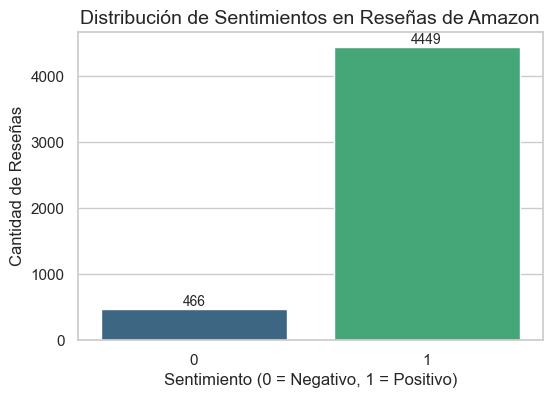

In [17]:

# Configuración del estilo
sns.set(style="whitegrid")

#  Gráfico de barras para la columna 'sentiment'
plt.figure(figsize=(6,4))
sns.countplot(data=data, x='sentiment', palette='viridis')

# Etiquetas y título
plt.title('Distribución de Sentimientos en Reseñas de Amazon', fontsize=14)
plt.xlabel('Sentimiento (0 = Negativo, 1 = Positivo)', fontsize=12)
plt.ylabel('Cantidad de Reseñas', fontsize=12)

# Mostrar etiquetas encima de las barras
for p in plt.gca().patches:
    plt.text(p.get_x() + p.get_width() / 2, 
             p.get_height() + 50, 
             f'{int(p.get_height())}', 
             ha='center', fontsize=10)

plt.show()


### Balanceo de clases para el análisis de sentimientos

En muchos conjuntos de datos de análisis de sentimientos (como reseñas de productos o servicios), suele existir un **desequilibrio entre clases**:  
por ejemplo, hay muchas más reseñas **positivas** que **negativas**.  
Esto puede hacer que el modelo aprenda a **favorecer la clase mayoritaria** y no logre identificar correctamente las minoritarias.

Para evitar ese sesgo, en esta etapa aplicamos una técnica llamada **undersampling** (submuestreo), que consiste en **reducir la cantidad de ejemplos de la clase mayoritaria** para igualarla con la clase minoritaria.  

1. Separamos las reseñas negativas (`sentiment == 0`) y las positivas (`sentiment == 1`).  
2. Tomamos una muestra aleatoria de reseñas positivas del mismo tamaño que las negativas (`n=len(negativos)`), garantizando equilibrio entre ambas.  
3. Unimos ambas muestras y las mezclamos aleatoriamente (`sample(frac=1)`) para evitar sesgos en el orden de los datos.  

El nuevo conjunto, llamado **`df_balanceado`**, tiene el mismo número de reseñas positivas y negativas, lo que permitirá entrenar modelos más **justos, estables y precisos**.

Finalmente, graficamos la **distribución de clases** para confirmar visualmente que el balanceo se ha realizado correctamente:
- El eje X representa las clases (`0 = Negativo`, `1 = Positivo`).
- El eje Y muestra la cantidad de reseñas en cada categoría.


C:\Users\jlvar\AppData\Local\Temp\ipykernel_32272\740073135.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_balanceado, x='sentiment', palette='viridis')


sentiment
1    466
0    466
Name: count, dtype: int64


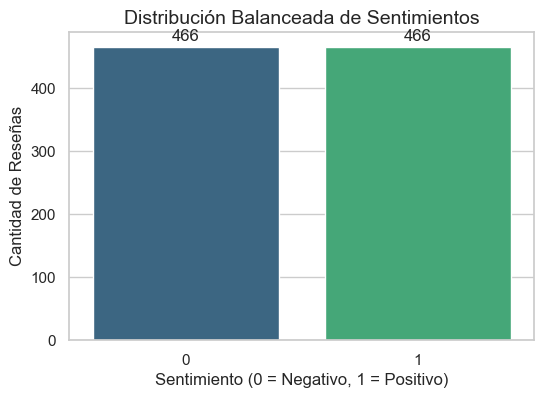

In [18]:
# Balancear las clases: undersampling de la clase positiva
negativos = data[data['sentiment'] == 0]
positivos = data[data['sentiment'] == 1].sample(n=len(negativos), random_state=42)

# Combinar ambos subconjuntos
df_balanceado = pd.concat([negativos, positivos]).sample(frac=1, random_state=42).reset_index(drop=True)

# Verificar el balance
print(df_balanceado['sentiment'].value_counts())

# Visualizar nuevamente
plt.figure(figsize=(6,4))
sns.countplot(data=df_balanceado, x='sentiment', palette='viridis')
plt.title('Distribución Balanceada de Sentimientos', fontsize=14)
plt.xlabel('Sentimiento (0 = Negativo, 1 = Positivo)')
plt.ylabel('Cantidad de Reseñas')

for p in plt.gca().patches:
    plt.text(p.get_x() + p.get_width() / 2, p.get_height() + 10, f'{int(p.get_height())}', ha='center')

plt.show()


In [19]:
df_balanceado = df_balanceado.drop(columns=['overall'])
df_balanceado.head()

,reviewText,sentiment
0,Great price for 32gb SD card; It was delivered...,1
1,This does not appear to work with the Samsung ...,0
2,Not a bad product at all. I got it for my blac...,1
3,The cards have had no reliability issues at th...,1
4,SanDisk is well know brand. The MSD Ultra 64 G...,1


## 2. Preprocesamiento del Texto

### Limpieza y normalización del texto

En esta etapa realizamos el **preprocesamiento del texto**, un paso esencial en cualquier proyecto de **Procesamiento de Lenguaje Natural (NLP)**.  
El objetivo es **eliminar ruido y unificar la estructura del texto** antes de aplicar técnicas de modelado o vectorización.

#### ¿Por qué limpiar el texto?
Los modelos de NLP aprenden patrones a partir de las palabras.  
Si el texto contiene ruido (símbolos, mayúsculas, URLs, etc.), el modelo podría **interpretar términos iguales como diferentes**  
(ejemplo: “Amazing” ≠ “amazing”) o **asignar importancia a caracteres sin valor semántico**.

#### Pasos aplicados en esta función:
1. **Conversión a minúsculas:**  
   Unifica el texto para que el modelo no distinga entre “Good” y “good”.

2. **Eliminación de URLs:**  
   Se remueven enlaces web con expresiones regulares (`re.sub(r'http\S+|www\S+', '', texto)`), ya que no aportan significado al análisis.

3. **Eliminación de caracteres especiales y números:**  
   Solo se conservan letras (`a-zA-Z`) y espacios.

4. **Tokenización:**  
   Divide el texto en palabras individuales usando `nltk.word_tokenize()`.

5. **Eliminación de *stopwords*:**  
   Se eliminan palabras vacías del inglés (como “the”, “is”, “at”), que no aportan información relev


In [20]:

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def limpiar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r'http\S+|www\S+|https\S+', '', texto)  # eliminar URLs
    texto = re.sub(r'[^a-zA-Z\s]', '', texto)               # eliminar caracteres especiales
    tokens = nltk.word_tokenize(texto)
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return ' '.join(tokens)

df_balanceado['clean_text'] = df_balanceado['reviewText'].apply(limpiar_texto)
df_balanceado.head()


,reviewText,sentiment,clean_text
0,Great price for 32gb SD card; It was delivered...,1,great price gb sd card delivered time got down...
1,This does not appear to work with the Samsung ...,0,appear work samsung galaxy worked week phone s...
2,Not a bad product at all. I got it for my blac...,1,bad product got blackberry z format phone soft...
3,The cards have had no reliability issues at th...,1,card reliability issue required task put data ...
4,SanDisk is well know brand. The MSD Ultra 64 G...,1,sandisk well know brand msd ultra gb class goo...


In [21]:
df_balanceado = df_balanceado.drop(columns=['reviewText'])
df_balanceado.head()

,sentiment,clean_text
0,1,great price gb sd card delivered time got down...
1,0,appear work samsung galaxy worked week phone s...
2,1,bad product got blackberry z format phone soft...
3,1,card reliability issue required task put data ...
4,1,sandisk well know brand msd ultra gb class goo...


## 3. Representación del Texto (Word Embeddings)

In [22]:

from gensim.models import Word2Vec

# Tokenizar las reseñas
tokens = [nltk.word_tokenize(text) for text in df_balanceado['clean_text']]
model_w2v = Word2Vec(sentences=tokens, vector_size=100, window=5, min_count=5, workers=4)

# Ejemplo: vector de una palabra
model_w2v.wv['good']

array([-0.20311202,  0.34792444,  0.18848695,  0.08221339,  0.27919033,
       -0.5462473 ,  0.1284753 ,  0.80705917, -0.22462796, -0.36152014,
       -0.3156931 , -0.5537309 ,  0.05064538,  0.208675  ,  0.15583064,
       -0.2021696 ,  0.0393751 , -0.28107435, -0.16135804, -0.87771237,
        0.12700576,  0.07070617,  0.03209697, -0.17540264, -0.10283455,
        0.04409419, -0.25708136, -0.37014967, -0.13438377,  0.09289388,
        0.3155359 ,  0.16752647,  0.11578625, -0.29346928, -0.28679055,
        0.563909  ,  0.13597472, -0.35491037, -0.19562782, -0.6724493 ,
        0.01475868, -0.20347235, -0.01509213, -0.08926835,  0.43605596,
       -0.06721345, -0.30144274, -0.00500543,  0.36276767,  0.04308349,
        0.21088602, -0.368997  , -0.02287295,  0.03689556, -0.30550304,
        0.21419467,  0.17136498, -0.11173118, -0.42327034,  0.22395043,
        0.15774725,  0.15591839, -0.06702383, -0.0611462 , -0.35335922,
        0.2475195 ,  0.06169252,  0.3594959 , -0.6040639 ,  0.49

## 4. Modelo Secuencial (LSTM/GRU)

###  Definición del modelo LSTM para análisis de sentimientos

En esta sección definimos la arquitectura del modelo **LSTM (Long Short-Term Memory)**,  
una red neuronal recurrente diseñada para procesar **secuencias de texto** y capturar dependencias a largo plazo.

#### ¿Qué es una LSTM?
Una **LSTM** es un tipo especial de red **Recurrent Neural Network (RNN)** que mejora la capacidad de recordar información  
a lo largo de secuencias largas (como frases o párrafos).  
A diferencia de una RNN tradicional, la LSTM incluye **mecanismos de control llamados compuertas** (*gates*):  
- **Forget Gate:** decide qué información se debe olvidar.  
- **Input Gate:** decide qué nueva información se almacena.  
- **Output Gate:** decide qué parte de la memoria se utiliza en la salida.

Esto le permite aprender **contextos semánticos** como:
> “no me gustó el producto” → tono negativo  
> “aunque tardó, el producto fue excelente” → tono positivo

####  Arquitectura del modelo
El modelo `SentimentLSTM` incluye:
1. **Capa de embeddings:** convierte cada palabra en un vector denso que representa su significado.  
2. **Capa LSTM bidireccional:** procesa el texto de izquierda a derecha y de derecha a izquierda para capturar contexto completo.  
3. **Capa fully connected (lineal):** toma la última salida de la LSTM y produce la predicción final (positivo o negativo).  
4. **Dropout:** técnica de regularización para evitar el sobreajuste (apaga aleatoriamente neuronas durante el entrenamiento).  

La salida final del modelo son **logits** (valores sin activar),  
que luego se procesarán con una función de pérdida como `CrossEntropyLoss` para obtener la clasificación del sentimiento.

> Esta arquitectura permite que el modelo “lea” las reseñas palabra por palabra,  
> aprenda patrones lingüísticos, recuerde dependencias entre palabras y  
> determine si el texto expresa un sentimiento positivo o negativo.


In [23]:
import torch.nn as nn

# Definición del modelo LSTM para clasificación de sentimientos
class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers=2, dropout=0.3, bidirectional=True):
        super(SentimentLSTM, self).__init__()

        # --- Capa de embeddings ---
        # Transforma los índices de palabras en vectores densos (representaciones semánticas)
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        
        # --- Capa LSTM ---
        # Procesa las secuencias palabra por palabra y mantiene una memoria de contexto
        # Se configura como bidireccional (lee de izquierda a derecha y viceversa)
        # con múltiples capas (n_layers) y dropout para evitar sobreajuste
        self.lstm = nn.LSTM(
            input_size=embedding_dim,      # Dimensión de entrada (embedding)
            hidden_size=hidden_dim,        # Número de neuronas en el estado oculto
            num_layers=n_layers,           # Número de capas apiladas LSTM
            bidirectional=bidirectional,   # Permite lectura en ambas direcciones
            batch_first=True,              # Las entradas tienen forma (batch, seq, feature)
            dropout=dropout                # Apaga neuronas aleatoriamente durante el entrenamiento
        )
        
        # --- Capa fully connected (clasificación) ---
        # Toma la salida final de la LSTM y la convierte en logits (valores para clasificación)
        direction_factor = 2 if bidirectional else 1  # Si es bidireccional, se duplican las salidas
        self.fc = nn.Linear(hidden_dim * direction_factor, output_dim)
        
        # --- Dropout adicional ---
        # Se aplica antes de la capa final para mejorar la generalización del modelo
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # Convierte los índices de palabras en vectores de embeddings
        embeds = self.embedding(x)

        # Pasa los embeddings por la LSTM
        lstm_out, _ = self.lstm(embeds)
        
        # Toma la última salida temporal de la secuencia (representación global del texto)
        out = self.dropout(lstm_out[:, -1, :])
        
        # Pasa la salida por la capa lineal para obtener los logits de clasificación
        out = self.fc(out)
        return out  # Sin softmax: se aplica automáticamente en CrossEntropyLoss



### Preparación de los datos para el modelo LSTM

En esta sección transformamos el texto limpio en una representación numérica que pueda ser entendida por el modelo de red neuronal.  
Este proceso incluye cinco pasos fundamentales:

1. **Tokenización:** convierte cada palabra en un número único según un vocabulario.  
2. **Padding:** ajusta todas las reseñas a la misma longitud (rellenando o truncando).  
3. **Asignación de etiquetas:** convierte las clases (positiva/negativa) en valores numéricos.  
4. **División de los datos:** separa el conjunto en entrenamiento (80%) y prueba (20%).  
5. **Creación de DataLoaders:** agrupa los tensores en mini-lotes para optimizar el entrenamiento.

Estos pasos aseguran que los datos tengan el formato adecuado para alimentar la red LSTM que clasificará el sentimiento de las reseñas.


In [24]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
import torch
import torch.nn as nn
import torch.optim as optim
from keras.preprocessing.text import Tokenizer
from keras.utils import pad_sequences
import numpy as np

# --- 1️ Tokenización del texto ---
# Se crea un tokenizador para convertir palabras en índices numéricos
tokenizer = Tokenizer()
tokenizer.fit_on_texts(df_balanceado['clean_text'])        # Aprende el vocabulario del corpus
sequences = tokenizer.texts_to_sequences(df_balanceado['clean_text'])  # Convierte texto → secuencias numéricas

# --- 2️ Padding ---
max_len = 100  # Longitud máxima de las reseñas (palabras por reseña)
# Ajusta todas las reseñas a la misma longitud (rellena con ceros o corta)
X = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')

# --- 3️ Etiquetas ---
# Extrae las etiquetas de sentimiento (0 = negativo, 1 = positivo)
y = df_balanceado['sentiment'].values

# --- 4️ División del conjunto de datos ---
# Separa los datos en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 5️ Conversión a tensores de PyTorch ---
X_train_t = torch.tensor(X_train, dtype=torch.long)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.long)
y_test_t = torch.tensor(y_test, dtype=torch.long)

# --- 6️ Creación de DataLoaders ---
batch_size = 32  # Tamaño de cada lote (batch)
# Crea conjuntos TensorDataset y los DataLoaders para entrenamiento y prueba
train_data = TensorDataset(X_train_t, y_train_t)
test_data = TensorDataset(X_test_t, y_test_t)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size)



In [25]:
# --- Definición de hiperparámetros del modelo LSTM ---

# Tamaño del vocabulario (número total de palabras únicas más un índice adicional)
# Se obtiene del tokenizador previamente entrenado
vocab_size = len(tokenizer.word_index) + 1  

# Dimensión de los vectores de embeddings (representación numérica de cada palabra)
# Cuanto mayor sea este valor, más información semántica puede representar cada palabra
embedding_dim = 100

# Dimensión del estado oculto de la LSTM (cantidad de neuronas internas)
# Controla la capacidad del modelo para aprender dependencias en el texto
hidden_dim = 128

# Número de clases de salida: 2 → (0 = negativo, 1 = positivo)
output_dim = 2  

# --- Inicialización del modelo ---
# Se crea una instancia de la red neuronal LSTM definida previamente
model = SentimentLSTM(vocab_size, embedding_dim, hidden_dim, output_dim)

# --- Función de pérdida ---
# Se utiliza CrossEntropyLoss, adecuada para problemas de clasificación multiclase
criterion = nn.CrossEntropyLoss()

# --- Optimizador ---
# Se emplea el optimizador Adam, que ajusta los pesos de la red
# a partir de los gradientes calculados durante el entrenamiento
optimizer = optim.Adam(model.parameters(), lr=0.001)



In [26]:
# --- Entrenamiento del modelo LSTM ---

# Número de épocas de entrenamiento (iteraciones completas sobre el conjunto de datos)
epochs = 50

# Cambiamos el modelo al modo entrenamiento (activa dropout, etc.)
model.train()

# Bucle principal de entrenamiento
for epoch in range(epochs):
    epoch_loss = 0  # Acumula la pérdida total por época

    # Itera sobre los lotes (batches) del conjunto de entrenamiento
    for inputs, labels in train_loader:
        optimizer.zero_grad()          # Reinicia los gradientes acumulados
        outputs = model(inputs)        # Realiza la predicción del modelo para el lote actual
        loss = criterion(outputs, labels)  # Calcula la pérdida comparando predicciones y etiquetas reales
        loss.backward()                # Calcula los gradientes por retropropagación
        optimizer.step()               # Actualiza los pesos del modelo según los gradientes
        epoch_loss += loss.item()      # Suma la pérdida del lote actual

    # Muest



✅ Accuracy:  76.47%
🎯 Precision: 0.7245
📈 Recall:    0.8068
💡 F1-score:  0.7634


<Figure size 500x400 with 0 Axes>

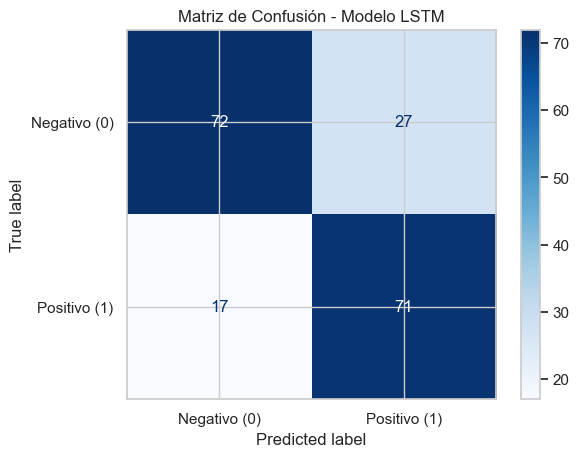

In [27]:
# --- Evaluación completa del modelo LSTM ---
# Cambiamos el modelo al modo evaluación (desactiva dropout y gradientes)
model.eval()

# Listas para almacenar predicciones y etiquetas reales
all_preds = []
all_labels = []

# Desactivamos el cálculo de gradientes (no se necesita durante la evaluación)
with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)               # Obtenemos las predicciones del modelo
        _, predicted = torch.max(outputs, 1)  # Seleccionamos la clase con mayor probabilidad
        all_preds.extend(predicted.cpu().numpy())  # Guardamos las predicciones
        all_labels.extend(labels.cpu().numpy())    # Guardamos las etiquetas reales

# --- Cálculo de métricas ---
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)

print(f"✅ Accuracy:  {accuracy * 100:.2f}%")
print(f"🎯 Precision: {precision:.4f}")
print(f"📈 Recall:    {recall:.4f}")
print(f"💡 F1-score:  {f1:.4f}")

# --- Matriz de confusión ---
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negativo (0)', 'Positivo (1)'])

plt.figure(figsize=(5,4))
disp.plot(cmap='Blues', values_format='d')
plt.title('Matriz de Confusión - Modelo LSTM')
plt.show()



In [28]:
def predecir_sentimiento(texto):
    seq = tokenizer.texts_to_sequences([texto])
    seq = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')
    seq_t = torch.tensor(seq, dtype=torch.long)
    model.eval()
    with torch.no_grad():
        output = model(seq_t)
        pred = torch.argmax(output, dim=1).item()
    return "Positivo 😀" if pred == 1 else "Negativo 😞"

# Ejemplo
print(predecir_sentimiento("The food was terrible and cold"))
print(predecir_sentimiento("Amazing service and delicious pizza!"))


Positivo 😀
Negativo 😞


In [29]:
torch.save(model.state_dict(), "sentiment_lstm_amz.pth")

## 5. Modelo basado en Transformers (BERT)

###  Introducción al modelo BERT para análisis de sentimientos

En esta sección utilizaremos **BERT (Bidirectional Encoder Representations from Transformers)**,  
un modelo preentrenado de lenguaje natural que revolucionó el campo del **Procesamiento de Lenguaje Natural (NLP)**  
al introducir una comprensión profunda del **contexto bidireccional** en los textos.

####  ¿Qué es BERT?

BERT es un modelo basado en la arquitectura **Transformer**, desarrollada por Google en 2018.  
Su principal característica es que **entiende el contexto de las palabras tanto hacia la izquierda como hacia la derecha** de una oración,  
gracias a su mecanismo de **auto-atención bidireccional (self-attention)**.

Por ejemplo, la palabra *“bank”* en:
- “I went to the **bank** to deposit money” → significa *banco financiero*  
- “The fisherman sat on the **bank** of the river” → significa *orilla del río*

Un modelo tradicional (como una LSTM) procesaría el texto palabra por palabra,  
y podría perder parte del contexto dependiendo de la dirección de lectura.  
BERT, en cambio, analiza toda la oración a la vez, capturando relaciones **simultáneas** entre todas las palabras.

#### ¿Cómo funciona BERT?

BERT se entrena previamente con dos tareas principales:

1. **Masked Language Modeling (MLM):**  
   Se ocultan aleatoriamente algunas palabras en una oración,  
   y el modelo aprende a predecir las palabras faltantes a partir del contexto.  
   Ejemplo:  
   > "The movie was [MASK]" → *great / terrible / boring...*

2. **Next Sentence Prediction (NSP):**  
   Se entrena para determinar si una oración sigue lógicamente a otra,  
   lo que le permite aprender relaciones entre frases.

Este preentrenamiento masivo (en miles de millones de palabras) permite que BERT entienda el lenguaje general,  
y luego pueda **ajustarse (fine-tuning)** a tareas específicas como:
- Clasificación de sentimientos   
- Preguntas y respuestas   
- Detección de spam   
- Reconocimiento de entidades nombradas  

####  El rol del **BertTokenizer**

El **tokenizador de BERT** convierte el texto en una secuencia de números (tokens) que el modelo puede procesar.  
A diferencia de un `Tokenizer` tradicional (como el usado en Keras), BERT:
- Divide palabras en **subpalabras** para manejar vocabularios más compactos.  
  - Ejemplo: “playing” → `["play", "##ing"]`  
- Añade **tokens especiales**:
  - `[CLS]` al inicio (representa la oración completa)  
  - `[SEP]` al final (separador de oraciones)
- Devuelve estructuras que BERT necesita:
  - `input_ids` → los IDs numéricos de los tokens  
  - `attention_mask` → indica qué tokens son reales y cuáles son padding  
  - `token_type_ids` → diferencia entre oraciones si hay más de una

Esto convierte el texto en tensores listos para el modelo.

**Carga del modelo preentrenado**

Utilizamos **BertForSequenceClassification**, una versión de BERT adaptada para tareas de **clasificación de texto**.  
El modelo ya tiene todas las capas de BERT más una **capa final de clasificación (fully connected)** para predecir el sentimiento.

Luego, ajustamos los parámetros para hacer **fine-tuning parcial**, es decir,  
solo entrenamos las **dos últimas capas del encoder** y la **capa de clasificación final**,  
dejando el resto del modelo **congelado** (no se actualizan sus pesos).  
Esto permite entrenar de manera más rápida y estable, especialmente con datasets medianos.

⚖️ **Diferencias clave entre LSTM y BERT**

| Característica | LSTM | BERT |
|----------------|------|------|
| **Arquitectura** | Red recurrente (procesa palabra a palabra) | Basado en Transformer (procesa todo el texto simultáneamente) |
| **Contexto** | Unidireccional (o bidireccional limitado) | Totalmente bidireccional |
| **Entrenamiento** | Desde cero, aprende desde el dataset | Preentrenado en lenguaje general y ajustado a la tarea |
| **Tokenización** | Palabras completas | Subpalabras (*WordPiece*) |
| **Velocidad de entrenamiento** | Más rápida en CPU, pero menos potente | Requiere GPU, pero captura mejor el contexto |
| **Resultados típicos** | Buen rendimiento en datasets pequeños | Resultados superiores en tareas complejas de lenguaje |




In [30]:
# --- Carga del modelo preentrenado BERT base ---

# Se carga el tokenizador correspondiente al modelo 'bert-base-uncased'
# Este tokenizador convierte el texto en secuencias numéricas compatibles con BERT,
# aplicando la codificación WordPiece, añadiendo tokens especiales y generando las máscaras de atención.
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Se carga el modelo BERT preentrenado para clasificación de secuencias
# 'num_labels=2' indica que se trata de un problema de clasificación binaria (positivo o negativo).
# Este modelo incluye todas las capas de BERT más una capa final fully connected para clasificar.
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

# --- Configuración de fine-tuning parcial ---
# Aquí definimos qué capas del modelo se ajustarán (entrenarán) y cuáles permanecerán congeladas.
# Solo se entrenan:
#   - La capa de clasificación final (classifier)
#   - Las dos últimas capas del encoder (encoder.layer.10 y encoder.layer.11)
# Esto acelera el entrenamiento y evita sobreajuste en datasets pequeños o medianos.
for name, param in model.named_parameters():
    if "classifier" in name or "encoder.layer.11" in name or "encoder.layer.10" in name:
        param.requires_grad = True   # Estas capas se entrenan
    else:
        param.requires_grad = False  # El resto se congela (no se actualizan los pesos)

# --- Ejemplo de tokenización y prueba del modelo ---
# Se tokeniza una frase de ejemplo, devolviendo tensores listos para ingresar al modelo.
# 'return_tensors="pt"' indica que los datos se devuelven en formato PyTorch (tensores).
sample = tokenizer("This product is amazing!", return_tensors="pt")

# Se pasa el texto tokenizado al modelo para obtener los logits (predicciones sin activar)
outputs = model(**sample)
logits = outputs.logits
# 'logits' contiene los valores de salida antes de aplicar softmax, que se usarán para determinar la clase predicha.
probs = torch.softmax(logits, dim=1)
print(probs)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


tensor([[0.5622, 0.4378]], grad_fn=<SoftmaxBackward0>)


### Creación del conjunto de datos personalizado para BERT

En esta sección se define la clase **`TextDataset`**, que prepara los textos y sus etiquetas para ser utilizados en el modelo BERT.  
Esta clase hereda de `torch.utils.data.Dataset`, la estructura estándar que PyTorch utiliza para manejar datos de entrenamiento.

El objetivo principal es **transformar cada reseña (texto)** en el formato numérico que BERT requiere, junto con su **etiqueta correspondiente** (por ejemplo, 0 = negativo, 1 = positivo).

#### ¿Por qué necesitamos una clase personalizada?

BERT no trabaja directamente con texto sin procesar, sino con **tensores numéricos** generados por su tokenizador (`BertTokenizer`).  
La clase `TextDataset` automatiza este proceso:  
cada vez que el modelo solicita un lote de datos, la clase se encarga de:

1. **Tokenizar el texto**: dividirlo en subpalabras y asignarles identificadores numéricos (`input_ids`).  
2. **Aplicar padding y truncamiento**: asegurar que todas las secuencias tengan la misma longitud (`max_len`).  
3. **Crear la máscara de atención (`attention_mask`)**: indica qué tokens son válidos y cuáles son relleno.  
4. **Asociar la etiqueta (`labels`)** con cada texto, para permitir el aprendizaje supervisado.

#### Funciones clave

- `__init__`: recibe los textos, etiquetas, tokenizador y longitud máxima.  
- `__len__`: devuelve el tamaño total del conjunto (número de ejemplos).  
- `__getitem__`: dado un índice, devuelve un ejemplo tokenizado y formateado como un diccionario con las claves:
  - **`input_ids`** → secuencia numérica del texto.  
  - **`attention_mask`** → máscara binaria (1 para tokens reales, 0 para padding).  
  - **`labels`** → clase del texto (entero 0 o 1).  

> Esta clase convierte automáticamente el texto limpio en la estructura que BERT necesita,  
> permitiendo que el `Trainer` de Hugging Face o un `DataLoader` de PyTorch lean los datos directamente y entrenen el modelo sin necesidad de procesamiento adicional.


In [31]:
# Definición de una clase personalizada para manejar el conjunto de datos de texto
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        # Guarda los textos (reseñas) y las etiquetas (sentimientos)
        self.texts = texts
        self.labels = labels
        # Tokenizador de BERT (convierte texto en secuencias numéricas)
        self.tokenizer = tokenizer
        # Longitud máxima para truncar o rellenar las secuencias
        self.max_len = max_len

    def __len__(self):
        # Devuelve el número total de ejemplos en el dataset
        return len(self.texts)

    def __getitem__(self, idx):
        # Toma el texto en la posición 'idx' y lo tokeniza
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,              # Corta textos más largos que max_len
            padding='max_length',         # Rellena textos más cortos hasta max_len
            max_length=self.max_len,      # Define longitud uniforme
            return_tensors='pt'           # Devuelve tensores de PyTorch
        )
        # Devuelve un diccionario con los tensores que BERT requiere
        return {
            'input_ids': enc['input_ids'].squeeze(0),            # Identificadores de tokens
            'attention_mask': enc['attention_mask'].squeeze(0),  # Máscara de atención
            'labels': torch.tensor(int(self.labels[idx]), dtype=torch.long)  # Etiqueta (0 o 1)
        }



In [32]:
# --- Preparación final de los conjuntos de entrenamiento y validación ---

X_train, X_val, y_train, y_val = train_test_split(
    df_balanceado["clean_text"], 
    df_balanceado["sentiment"], 
    test_size=0.2, 
    random_state=42,
    stratify=df_balanceado["sentiment"]
)

# Tras aplicar train_test_split, las variables X_train, X_val, y_train y y_val
# son objetos de tipo pandas Series con índices heredados del DataFrame original.
# Estos índices pueden causar errores al acceder por posición dentro del Dataset personalizado.
# Por eso, se restablecen los índices y se convierten las Series en listas.

# Restablece los índices (drop=True evita que se agregue una nueva columna con el índice anterior)
# Luego convierte los datos a listas para indexarlos fácilmente dentro de la clase TextDataset
X_train = X_train.tolist()
X_val   = X_val.tolist()
y_train = y_train.tolist()
y_val   = y_val.tolist()

# --- Creación de los datasets personalizados ---
# Se instancian los conjuntos de datos de entrenamiento y validación
# utilizando la clase TextDataset definida previamente.
# Esta clase aplica la tokenización y prepara los tensores de entrada y etiquetas
# para que puedan ser usados por el modelo BERT.

train_ds = TextDataset(X_train, y_train, tokenizer, max_len=128)
val_ds   = TextDataset(X_val,   y_val,   tokenizer, max_len=128)



In [33]:

# --- Configuración del Collator, las métricas y el entrenador de BERT ---

# --- 1️ Data Collator ---
# El DataCollatorWithPadding se encarga de aplicar padding dinámico a cada lote (batch)
# durante el entrenamiento. Esto significa que las secuencias más cortas se rellenan
# automáticamente al tamaño del texto más largo del lote, optimizando el uso de memoria.
# Es esencial cuando se trabaja con modelos como BERT que requieren entradas de longitud uniforme.
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


# --- 2️ Función de métricas ---
# compute_metrics define las métricas que se evaluarán al final de cada época de entrenamiento.
# EvalPrediction (eval_pred) contiene dos elementos:
#   - logits: las predicciones sin activar del modelo (salidas brutas)
#   - labels: las etiquetas reales
# Se calculan métricas clave de rendimiento:
#   - accuracy: proporción de aciertos totales
#   - precision: porcentaje de predicciones positivas correctas
#   - recall: porcentaje de positivos reales correctamente identificados
#   - f1: media armónica entre precisión y recall
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=1)  # Selecciona la clase con mayor probabilidad
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average='binary', zero_division=0)
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc, 'precision': p, 'recall': r, 'f1': f1}


# --- 3️ Argumentos de entrenamiento ---
# Aquí se configuran los hiperparámetros y estrategias del proceso de entrenamiento.
training_args = TrainingArguments(
    output_dir='./results_bert',           # Carpeta donde se guardan los resultados y checkpoints
    eval_strategy='epoch',                 # Evalúa el modelo al final de cada época
    save_strategy='epoch',                 # Guarda el modelo al final de cada época
    load_best_model_at_end=True,           # Carga el mejor modelo (según la métrica elegida) al finalizar
    metric_for_best_model='f1',            # Métrica principal usada para determinar el mejor modelo
    greater_is_better=True,                # Indica que un F1 mayor es mejor
    learning_rate=2e-5,                    # Tasa de aprendizaje típica para BERT
    per_device_train_batch_size=8,         # Tamaño del lote para entrenamiento
    per_device_eval_batch_size=8,          # Tamaño del lote para evaluación
    num_train_epochs=3,                    # Número de épocas de entrenamiento
    weight_decay=0.01,                     # Penalización L2 para evitar sobreajuste
    logging_dir='./logs_bert',             # Carpeta donde se almacenan los logs
    logging_steps=50,                      # Frecuencia de registro (cada 50 pasos)
    save_total_limit=1,                    # Mantiene solo el último checkpoint guardado
    fp16=torch.cuda.is_available(),        # Usa media precisión (16 bits) si hay GPU disponible
    seed=42,                               # Fija la semilla para reproducibilidad
)


# --- 4️ Configuración del Trainer ---
# El objeto Trainer de Hugging Face gestiona todo el proceso de entrenamiento y evaluación.
# Integra automáticamente el modelo, los datasets, el optimizador, las métricas y los argumentos definidos.
trainer = Trainer(
    model=model,                           # Modelo BERT para clasificación
    args=training_args,                    # Parámetros y estrategias de entrenamiento
    train_dataset=train_ds,                # Conjunto de entrenamiento
    eval_dataset=val_ds,                   # Conjunto de validación
    tokenizer=tokenizer,                   # Tokenizador de BERT
    data_collator=data_collator,           # Collator para aplicar padding dinámico
    compute_metrics=compute_metrics,       # Función de métricas personalizadas
)



In [34]:
trainer.train()

  0%|          | 0/282 [00:00<?, ?it/s]c:\Users\jlvar\anaconda3\envs\llm\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
 18%|█▊        | 50/282 [01:33<07:07,  1.84s/it]

{'loss': 0.6681, 'grad_norm': 3.133334159851074, 'learning_rate': 1.645390070921986e-05, 'epoch': 0.53}


                                                
 33%|███▎      | 94/282 [03:22<04:31,  1.44s/it]

{'eval_loss': 0.5611143708229065, 'eval_accuracy': 0.732620320855615, 'eval_precision': 0.672, 'eval_recall': 0.9032258064516129, 'eval_f1': 0.7706422018348624, 'eval_runtime': 26.3879, 'eval_samples_per_second': 7.087, 'eval_steps_per_second': 0.91, 'epoch': 1.0}


c:\Users\jlvar\anaconda3\envs\llm\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
 35%|███▌      | 100/282 [03:37<10:44,  3.54s/it]

...

                                                 
100%|██████████| 282/282 [09:48<00:00,  1.28s/it]

{'eval_loss': 0.4258337914943695, 'eval_accuracy': 0.8074866310160428, 'eval_precision': 0.8352941176470589, 'eval_recall': 0.7634408602150538, 'eval_f1': 0.797752808988764, 'eval_runtime': 20.4176, 'eval_samples_per_second': 9.159, 'eval_steps_per_second': 1.175, 'epoch': 3.0}


100%|██████████| 282/282 [09:49<00:00,  2.09s/it]

{'train_runtime': 589.5001, 'train_samples_per_second': 3.791, 'train_steps_per_second': 0.478, 'train_loss': 0.5237289117583146, 'epoch': 3.0}


TrainOutput(global_step=282, training_loss=0.5237289117583146, metrics={'train_runtime': 589.5001, 'train_samples_per_second': 3.791, 'train_steps_per_second': 0.478, 'total_flos': 147013302182400.0, 'train_loss': 0.5237289117583146, 'epoch': 3.0})

In [35]:
#  evaluar y guardar

metrics = trainer.evaluate()
print(metrics)

trainer.save_model('./bert_amz_partial_ft')
tokenizer.save_pretrained('./bert_amz_partial_ft')

c:\Users\jlvar\anaconda3\envs\llm\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
100%|██████████| 24/24 [00:21<00:00,  1.13it/s]


{'eval_loss': 0.4258337914943695, 'eval_accuracy': 0.8074866310160428, 'eval_precision': 0.8352941176470589, 'eval_recall': 0.7634408602150538, 'eval_f1': 0.797752808988764, 'eval_runtime': 22.0285, 'eval_samples_per_second': 8.489, 'eval_steps_per_second': 1.089, 'epoch': 3.0}


('./bert_amz_partial_ft\\tokenizer_config.json',
 './bert_amz_partial_ft\\special_tokens_map.json',
 './bert_amz_partial_ft\\vocab.txt',
 './bert_amz_partial_ft\\added_tokens.json')

In [36]:
# ---  Predicción en texto nuevo
def predict_text(text, max_len=128):
    enc = tokenizer(text, truncation=True, padding='max_length',
                    max_length=max_len, return_tensors='pt')
    with torch.no_grad():
        out = model(**{k: v.to(model.device) for k, v in enc.items()})
        probs = torch.softmax(out.logits, dim=-1).cpu().numpy().ravel()
    pred = int(probs.argmax())
    return {'pred': pred, 'probs': probs}  # 0=neg, 1=pos

print(predict_text("Amazing food and great service!"))
print(predict_text("Terrible experience, I won't come back."))

{'pred': 1, 'probs': array([0.16040224, 0.8395977 ], dtype=float32)}
{'pred': 0, 'probs': array([0.5576318 , 0.44236818], dtype=float32)}
